In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. VERİ YOLLARININ VE PARAMETRELERİN TANIMLANMASI
base_path = r'c:\Users\mehmet\Desktop\XRay_SVM_Project\COVID-19_Radiography_Dataset'
categories = ['COVID', 'Normal', 'Viral Pneumonia']
target_size = (200, 200) 
sample_per_category = 1300 

data = []
labels = []

print(f">>> Veri seti yükleme işlemi başlatıldı...")
print(f">>> Hedef: Her sınıftan {sample_per_category} örnek, Boyut: {target_size}\n")

# 2. VERİLERİN DENGELİ OLARAK OKUNMASI
for i, category in enumerate(categories):
    path = os.path.join(base_path, category)
    images = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    # Sınıf dengesi için kısıtlama
    count = 0
    for img_name in tqdm(images, desc=f'Yükleniyor: {category}'):
        if count >= sample_per_category:
            break
            
        try:
            img_path = os.path.join(path, img_name)
            # PDF'deki gibi grayscale okuma
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            # Kullanıcı isteği: 200x200 boyutlandırma
            img_resized = cv2.resize(img, target_size)
            
            data.append(img_resized)
            labels.append(i)
            count += 1
        except Exception as e:
            continue

# Numpy dizilerine dönüştürme
X = np.array(data)
y = np.array(labels)

# 3. SUNUM İÇİN ÇIKTILARIN ÜRETİLMESİ

# Çıktı A: Konsol Özet Tablosu
summary_df = pd.DataFrame({
    'Sınıf Adı': categories,
    'Etiket': [0, 1, 2],
    'Örnek Sayısı': [np.sum(y == i) for i in range(len(categories))],
    'Görüntü Boyutu': [f"{target_size[0]}x{target_size[1]}" for _ in range(3)]
})

print("\n" + "="*50)
print("📊 VERİ SETİ ÖZET TABLOSU (SUNUM İÇİN)")
print("="*50)
print(summary_df.to_string(index=False))
print("="*50)

# Çıktı B: Örnek Görüntülerin Görselleştirilmesi
plt.figure(figsize=(15, 5))
for i in range(len(categories)):
    # Her sınıftan ilk örneği göster
    idx = np.where(y == i)[0][0]
    plt.subplot(1, 3, i+1)
    plt.imshow(X[idx], cmap='gray')
    plt.title(f"Sınıf: {categories[i]}\n(Etiket: {i})", fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle(f"Yüklenen Veri Setinden Örnekler ({target_size[0]}x{target_size[1]})", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

>>> Veri seti yükleme işlemi başlatıldı...
>>> Hedef: Her sınıftan 1300 örnek, Boyut: (200, 200)



Yükleniyor: COVID: 0it [00:00, ?it/s]
Yükleniyor: Normal: 0it [00:00, ?it/s]
Yükleniyor: Viral Pneumonia: 0it [00:00, ?it/s]


📊 VERİ SETİ ÖZET TABLOSU (SUNUM İÇİN)
      Sınıf Adı  Etiket  Örnek Sayısı Görüntü Boyutu
          COVID       0             0        200x200
         Normal       1             0        200x200
Viral Pneumonia       2             0        200x200


IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 1500x500 with 0 Axes>

>>> Veri seti yükleme işlemi başlatıldı...
🔍 Aranan yol: c:\Users\mehmet\Desktop\XRay_SVM_Project\COVID-19_Radiography_Dataset\COVID\images


Yükleniyor: COVID:  36%|███▌      | 1300/3616 [00:02<00:03, 647.17it/s]


🔍 Aranan yol: c:\Users\mehmet\Desktop\XRay_SVM_Project\COVID-19_Radiography_Dataset\Normal\images


Yükleniyor: Normal:  13%|█▎        | 1300/10192 [00:01<00:11, 802.10it/s]


🔍 Aranan yol: c:\Users\mehmet\Desktop\XRay_SVM_Project\COVID-19_Radiography_Dataset\Viral Pneumonia\images


Yükleniyor: Viral Pneumonia:  97%|█████████▋| 1300/1345 [00:05<00:00, 219.75it/s]



📊 VERİ SETİ ÖZET TABLOSU (SUNUM İÇİN)
      Sınıf Adı  Etiket  Örnek Sayısı Görüntü Boyutu
          COVID       0          1300        200x200
         Normal       1          1300        200x200
Viral Pneumonia       2          1300        200x200


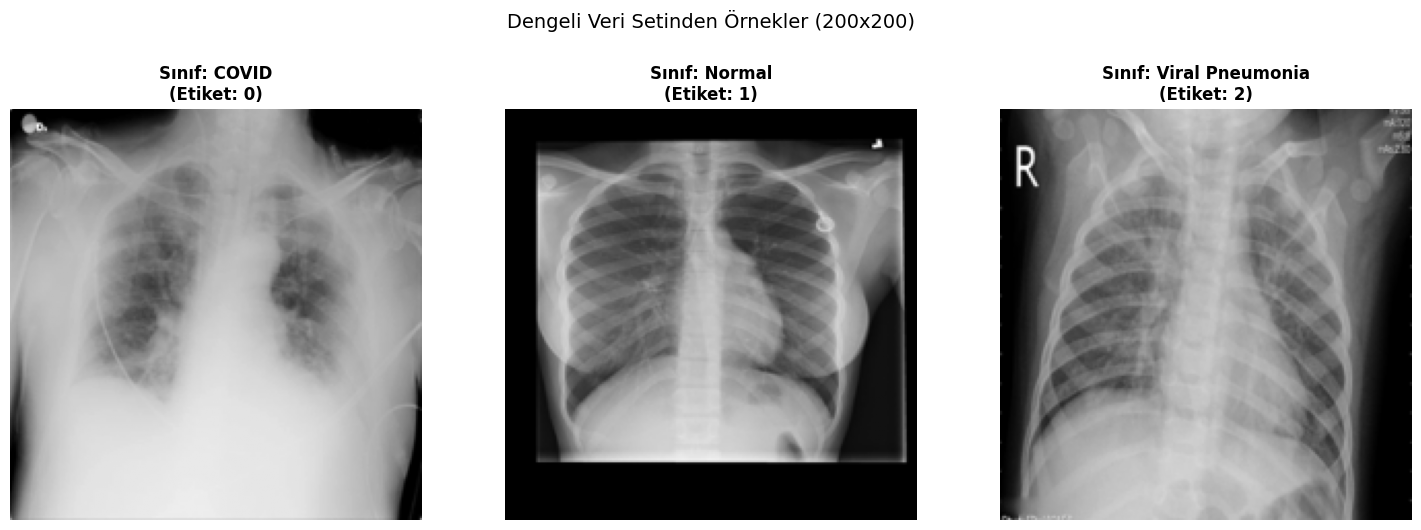

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. VERİ YOLLARININ VE PARAMETRELERİN TANIMLANMASI
base_path = r'c:\Users\mehmet\Desktop\XRay_SVM_Project\COVID-19_Radiography_Dataset'
categories = ['COVID', 'Normal', 'Viral Pneumonia']
target_size = (200, 200) 
sample_per_category = 1300 

data = []
labels = []

print(f">>> Veri seti yükleme işlemi başlatıldı...")

for i, category in enumerate(categories):
    # Ana kategori yolu
    category_path = os.path.join(base_path, category)
    
    # Hata önleme: Eğer kategori klasörünün içinde 'images' diye bir alt klasör varsa onu kullan
    if os.path.exists(os.path.join(category_path, 'images')):
        search_path = os.path.join(category_path, 'images')
    else:
        search_path = category_path
        
    print(f"🔍 Aranan yol: {search_path}")
    
    # Dosyaları listele
    images = [f for f in os.listdir(search_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if len(images) == 0:
        print(f"⚠️ UYARI: {search_path} içinde resim bulunamadı!")
        continue

    count = 0
    for img_name in tqdm(images, desc=f'Yükleniyor: {category}'):
        if count >= sample_per_category:
            break
            
        try:
            img_path = os.path.join(search_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            
            img_resized = cv2.resize(img, target_size)
            data.append(img_resized)
            labels.append(i)
            count += 1
        except Exception as e:
            continue

# Numpy dizilerine dönüştürme (Sadece veri bulunduysa)
if len(data) > 0:
    X = np.array(data)
    y = np.array(labels)

    # SUNUM ÇIKTILARI
    summary_df = pd.DataFrame({
        'Sınıf Adı': categories,
        'Etiket': [0, 1, 2],
        'Örnek Sayısı': [np.sum(y == i) for i in range(len(categories))],
        'Görüntü Boyutu': [f"{target_size[0]}x{target_size[1]}" for _ in range(3)]
    })

    print("\n" + "="*50)
    print("📊 VERİ SETİ ÖZET TABLOSU (SUNUM İÇİN)")
    print("="*50)
    print(summary_df.to_string(index=False))
    
    plt.figure(figsize=(15, 5))
    for i in range(len(categories)):
        indices = np.where(y == i)[0]
        if len(indices) > 0:
            idx = indices[0]
            plt.subplot(1, 3, i+1)
            plt.imshow(X[idx], cmap='gray')
            plt.title(f"Sınıf: {categories[i]}\n(Etiket: {i})", fontsize=12, fontweight='bold')
            plt.axis('off')
    plt.suptitle(f"Dengeli Veri Setinden Örnekler ({target_size[0]}x{target_size[1]})", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("❌ HATA: Hiçbir veri yüklenemedi. Lütfen klasör yollarını kontrol edin.")

>>> PCA (Boyut İndirgeme) işlemi başlatılıyor...

--- ÖZELLİK MÜHENDİSLİĞİ VE BOYUT İNDİRGEME ÖZETİ ---
                 Parametre          Değer
   Orijinal Özellik Sayısı 40000 (Piksel)
PCA Sonrası Bileşen Sayısı   191 (Vektör)
  Açıklanan Toplam Varyans         %95.02


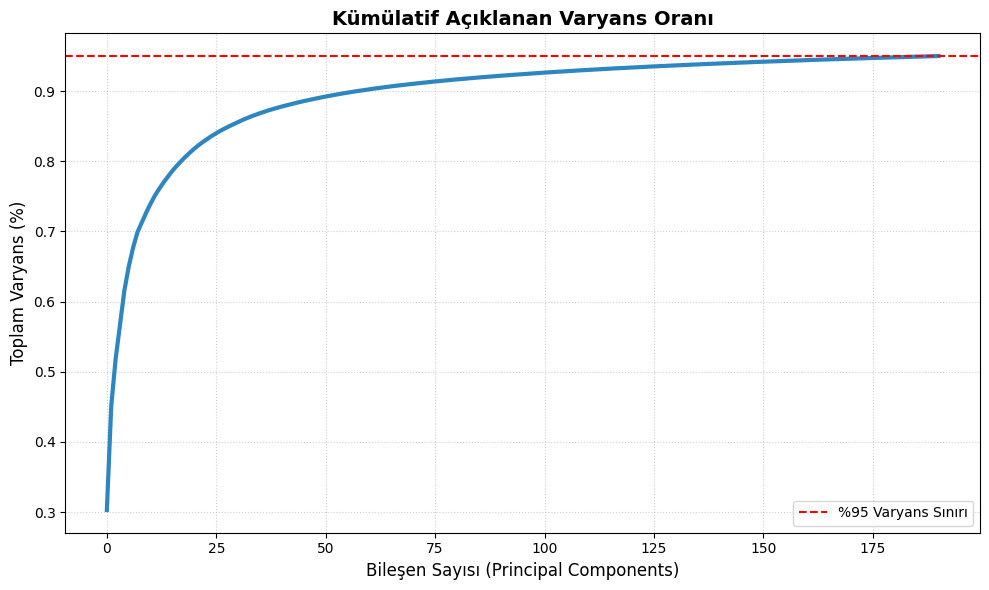

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. VERİYİ DÜZLEŞTİRME VE NORMALİZASYON
# 2D görüntüleri (200, 200) -> 1D vektöre (40.000) dönüştürüyoruz
X_flat = X.reshape(len(X), -1)

# Pikselleri 0-1 arasına çekiyoruz
X_normalized = X_flat.astype('float32') / 255.0

print(f">>> PCA (Boyut İndirgeme) işlemi başlatılıyor...")

# 2. PCA UYGULAMASI
# Verideki bilginin (varyansın) %95'ini koruyacak kadar bileşen seçiyoruz
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_normalized)

# 3. SONUÇLARIN ANALİZİ VE TABLO OLUŞTURMA
n_components = pca.n_components_
explained_variance = np.sum(pca.explained_variance_ratio_) * 100

pca_summary = pd.DataFrame({
    "Parametre": ["Orijinal Özellik Sayısı", "PCA Sonrası Bileşen Sayısı", "Açıklanan Toplam Varyans"],
    "Değer": [f"{X_flat.shape[1]} (Piksel)", f"{n_components} (Vektör)", f"%{explained_variance:.2f}"]
})

# Tabloyu yazdır
print("\n--- ÖZELLİK MÜHENDİSLİĞİ VE BOYUT İNDİRGEME ÖZETİ ---")
print(pca_summary.to_string(index=False))

# 4. PROFESYONEL SCREE PLOT ÇİZİMİ
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), linewidth=3, color='#2E86C1')
plt.axhline(y=0.95, color='r', linestyle='--', label='%95 Varyans Sınırı')

plt.title('Kümülatif Açıklanan Varyans Oranı', fontsize=14, fontweight='bold')
plt.xlabel('Bileşen Sayısı (Principal Components)', fontsize=12)
plt.ylabel('Toplam Varyans (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

>>> Veri bölme senaryoları test ediliyor...

--- VERİ BÖLME SENARYOLARI PERFORMANS TABLOSU ---
              Senaryo  Eğitim Seti  Doğrulama Seti  Test Seti Validasyon Başarısı Test Başarısı
Senaryo A (%80-10-10)         3120             390        390              %90.77        %91.28
Senaryo B (%70-15-15)         2730             585        585              %89.91        %91.45


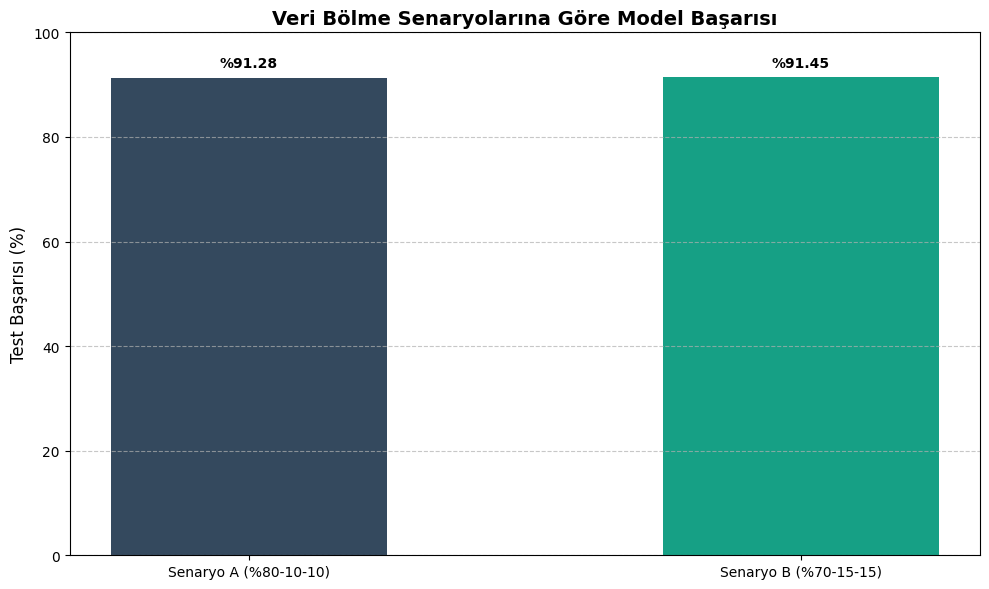

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Karşılaştırma sonuçlarını saklamak için liste
split_results = []

# Denenecek senaryolar (Eğitim-Validasyon-Test oranları)
scenarios = [
    {"name": "Senaryo A (%80-10-10)", "train": 0.80, "val": 0.10, "test": 0.10},
    {"name": "Senaryo B (%70-15-15)", "train": 0.70, "val": 0.15, "test": 0.15}
]

print(">>> Veri bölme senaryoları test ediliyor...\n")

for sc in scenarios:
    # 1. İlk bölme: Eğitim ve (Validasyon+Test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_pca, y, train_size=sc["train"], random_state=42, stratify=y
    )
    
    # 2. İkinci bölme: Geçici seti Validasyon ve Test olarak ikiye ayırma
    # Kalan veriyi (1 - train_size) içindeki val/test oranına göre bölüyoruz
    relative_val_size = sc["val"] / (sc["val"] + sc["test"])
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=relative_val_size, random_state=42, stratify=y_temp
    )
    
    # Karşılaştırma için standart bir RBF SVM eğitiyoruz
    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train, y_train)
    
    # Tahminler ve Skorlar
    val_acc = accuracy_score(y_val, model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    split_results.append({
        "Senaryo": sc["name"],
        "Eğitim Seti": len(X_train),
        "Doğrulama Seti": len(X_val),
        "Test Seti": len(X_test),
        "Validasyon Başarısı": f"%{val_acc*100:.2f}",
        "Test Başarısı": f"%{test_acc*100:.2f}",
        "Test_Raw": test_acc * 100
    })

# 3. TABLO ÇIKTISI
df_splits = pd.DataFrame(split_results)
print("--- VERİ BÖLME SENARYOLARI PERFORMANS TABLOSU ---")
print(df_splits.drop(columns=["Test_Raw"]).to_string(index=False))

# 4. GRAFİK ÇIKTISI
plt.figure(figsize=(10, 6))
bars = plt.bar(df_splits["Senaryo"], df_splits["Test_Raw"], color=['#34495E', '#16A085'], width=0.5)

plt.title('Veri Bölme Senaryolarına Göre Model Başarısı', fontsize=14, fontweight='bold')
plt.ylabel('Test Başarısı (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Barların üzerine değer yazma
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"%{yval:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

>>> SVM Çekirdek Yarışması Başlatıldı...

✅ LINEAR Çekirdek Tamamlandı. Başarı: %83.59
✅ POLY Çekirdek Tamamlandı. Başarı: %88.72
✅ RBF Çekirdek Tamamlandı. Başarı: %91.45

--- SVM ÇEKİRDEK PERFORMANS KARŞILAŞTIRMA ÇİZELGESİ ---
Çekirdek (Kernel)  Eğitim Süresi (sn)  Accuracy  Precision  Recall  F1-Score
           LINEAR                7.06     83.59      83.60   83.59     83.59
             POLY                0.23     88.72      88.65   88.72     88.67
              RBF                0.23     91.45      91.57   91.45     91.47


<Figure size 1200x700 with 0 Axes>

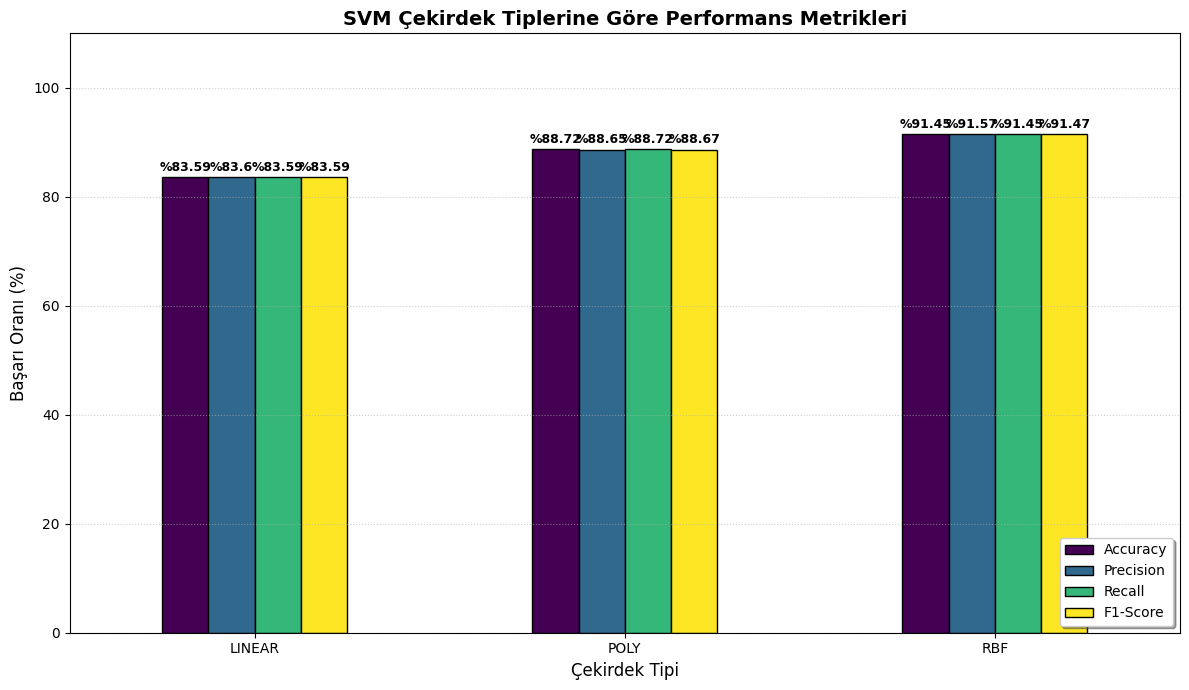

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import time

# 1. EN BAŞARILI SENARYO İLE VERİYİ TEKRAR BÖLME (%70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(X_pca, y, train_size=0.70, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.50, random_state=42, stratify=y_temp)

# Denenecek çekirdekler
kernels = ['linear', 'poly', 'rbf']
kernel_results = []

print(">>> SVM Çekirdek Yarışması Başlatıldı...\n")

for knl in kernels:
    start_time = time.time()
    
    # Modeli eğitme
    model = SVC(kernel=knl, random_state=42)
    model.fit(X_train, y_train)
    
    # Tahminler
    y_pred = model.predict(X_test)
    end_time = time.time()
    
    # Metrikler
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    kernel_results.append({
        "Çekirdek (Kernel)": knl.upper(),
        "Eğitim Süresi (sn)": round(end_time - start_time, 2),
        "Accuracy": round(acc * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2),
        "F1-Score": round(f1 * 100, 2)
    })
    print(f"✅ {knl.upper()} Çekirdek Tamamlandı. Başarı: %{acc*100:.2f}")

# 2. KARŞILAŞTIRMA TABLOSU
df_kernels = pd.DataFrame(kernel_results)
print("\n--- SVM ÇEKİRDEK PERFORMANS KARŞILAŞTIRMA ÇİZELGESİ ---")
print(df_kernels.to_string(index=False))

# 3. PROFESYONEL KARŞILAŞTIRMA GRAFİĞİ
plt.figure(figsize=(12, 7))
ax = df_kernels.plot(x='Çekirdek (Kernel)', y=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
                    kind='bar', figsize=(12, 7), colormap='viridis', edgecolor='black')

plt.title('SVM Çekirdek Tiplerine Göre Performans Metrikleri', fontsize=14, fontweight='bold')
plt.ylabel('Başarı Oranı (%)', fontsize=12)
plt.xlabel('Çekirdek Tipi', fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.xticks(rotation=0)

# Barların üzerine değer yazma
for p in ax.patches:
    ax.annotate(f"%{p.get_height()}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 7),
                textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

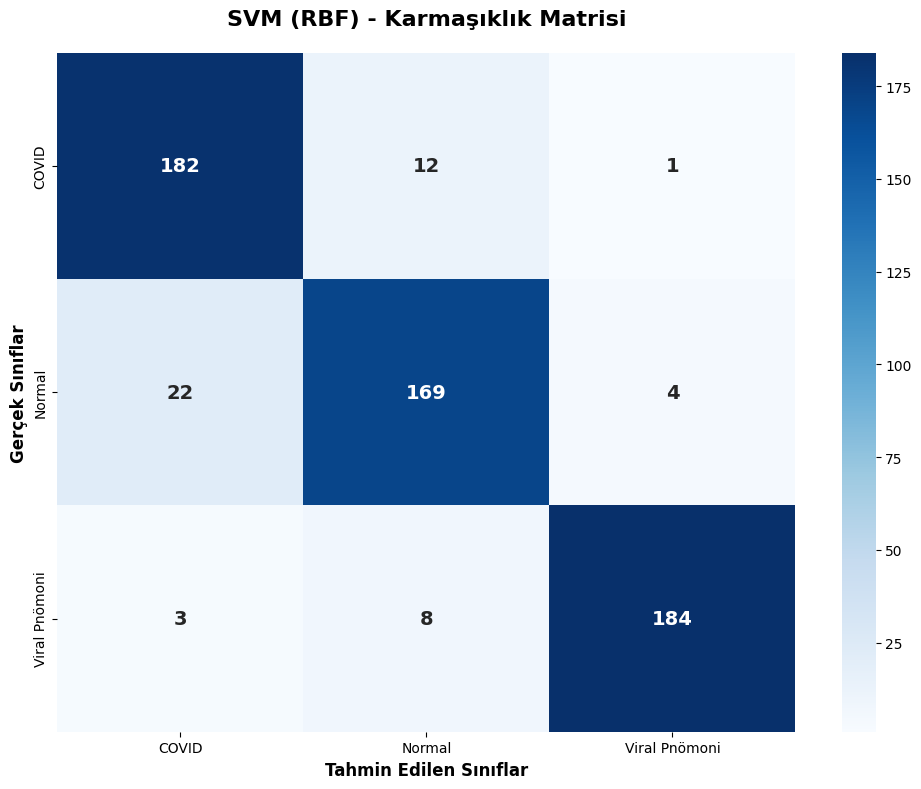

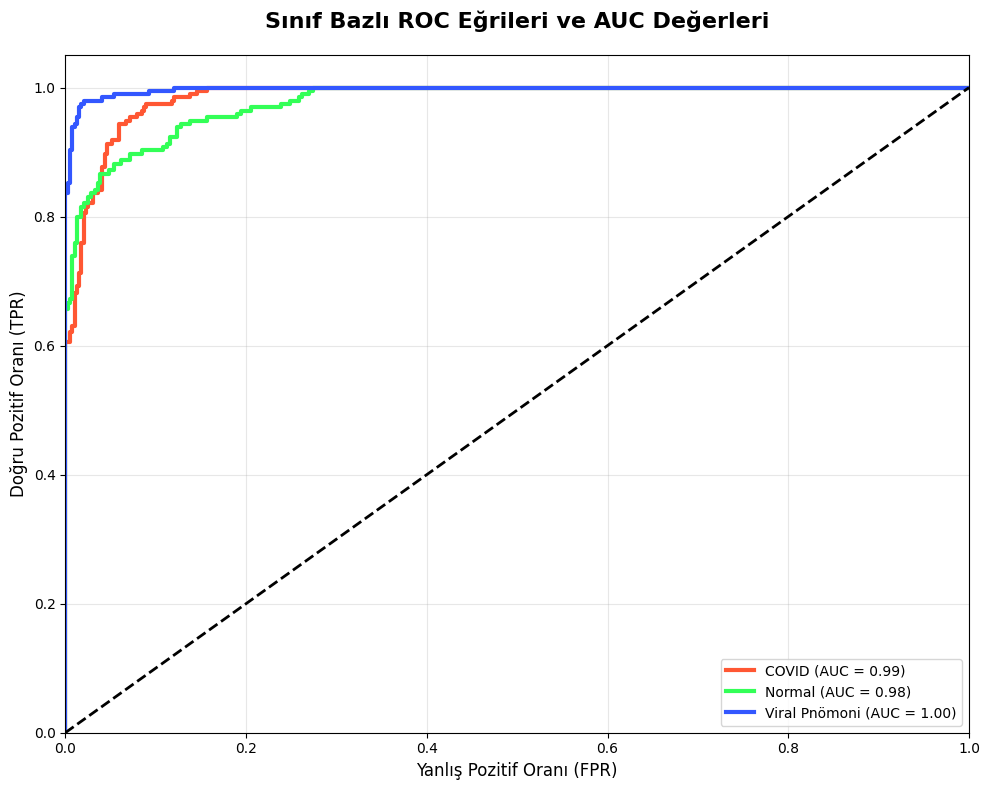


📌 FİNAL MODEL PERFORMANS RAPORU
               precision    recall  f1-score   support

        COVID       0.88      0.93      0.91       195
       Normal       0.89      0.87      0.88       195
Viral Pnömoni       0.97      0.94      0.96       195

     accuracy                           0.91       585
    macro avg       0.92      0.91      0.91       585
 weighted avg       0.92      0.91      0.91       585



In [6]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. EN İYİ MODELİN (RBF) EĞİTİLMESİ VE TAHMİN
final_model = SVC(kernel='rbf', probability=True, random_state=42)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_score = final_model.predict_proba(X_test) # ROC eğrisi için olasılık değerleri

# 2. PROFESYONEL KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX)
cm = confusion_matrix(y_test, y_pred)
categories = ['COVID', 'Normal', 'Viral Pnömoni']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories,
            annot_kws={"size": 14, "weight": "bold"})

plt.title('SVM (RBF) - Karmaşıklık Matrisi', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Gerçek Sınıflar', fontsize=12, fontweight='bold')
plt.xlabel('Tahmin Edilen Sınıflar', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. ÇOKLU SINIF ROC EĞRİSİ (ROC CURVE)
# Etiketleri binarize ediyoruz (0,1,2 -> [1,0,0], [0,1,0], [0,0,1])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()
colors = ['#FF5733', '#33FF57', '#3357FF']

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=3,
             label=f'{categories[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Sınıf Bazlı ROC Eğrileri ve AUC Değerleri', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=12)
plt.ylabel('Doğru Pozitif Oranı (TPR)', fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. FİNAL SINIFLANDIRMA RAPORU
print("\n" + "="*60)
print("📌 FİNAL MODEL PERFORMANS RAPORU")
print("="*60)
print(classification_report(y_test, y_pred, target_names=categories))
print("="*60)

>>> Öğrenme Eğrileri hesaplanıyor (Bu işlem biraz zaman alabilir)...


c:\Users\mehmet\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\mehmet\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\mehmet\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\mehmet\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\svm\_base.py", line 207, in fit
    y = self._validate_tar

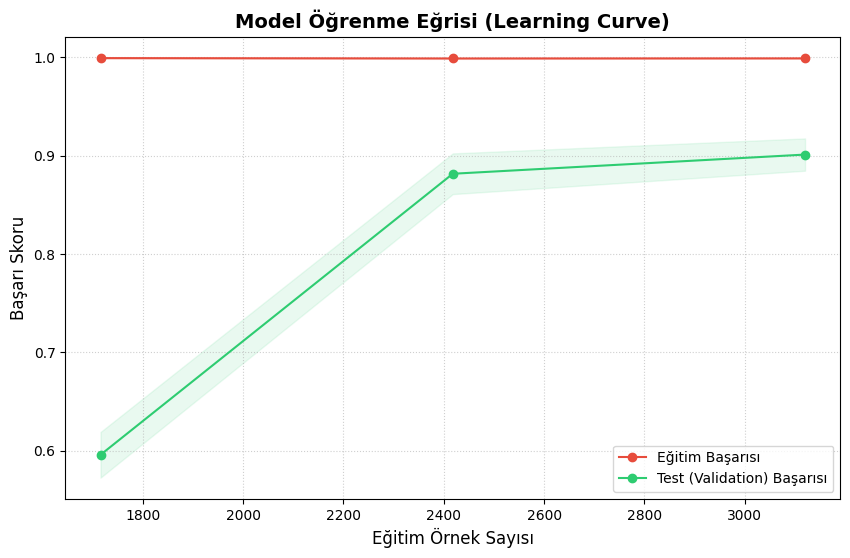


>>> 2. ADIM: HİPERPARAMETRE OPTİMİZASYONU (GRID SEARCH)
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ En İyi Parametreler: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
✅ En İyi Eğitim Skoru: %90.29
✅ Final Test Başarısı (Optimize Edilmiş): %92.99


In [7]:
from sklearn.model_selection import learning_curve, GridSearchCV
import matplotlib.pyplot as plt
import numpy as np

# 1. ÖĞRENME EĞRİSİ (TRAIN VS TEST SUCCESS) ÇİZİMİ
print(">>> Öğrenme Eğrileri hesaplanıyor (Bu işlem biraz zaman alabilir)...")

train_sizes, train_scores, test_sizes = learning_curve(
    SVC(kernel='rbf', C=10, gamma='scale'), X_pca, y, 
    train_sizes=np.linspace(0.1, 1.0, 5), cv=5, n_jobs=-1
)

# Skorların ortalamasını ve standart sapmasını hesaplama
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_sizes, axis=1)
test_std = np.std(test_sizes, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#E74C3C", label="Eğitim Başarısı")
plt.plot(train_sizes, test_mean, 'o-', color="#2ECC71", label="Test (Validation) Başarısı")

# Başarı aralıklarını renklendirme (Güven aralığı)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#E74C3C")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ECC71")

plt.title('Model Öğrenme Eğrisi (Learning Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Eğitim Örnek Sayısı', fontsize=12)
plt.ylabel('Başarı Skoru', fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\n" + "="*50)
print(">>> 2. ADIM: HİPERPARAMETRE OPTİMİZASYONU (GRID SEARCH)")
print("="*50)

# 2. GRID SEARCH İLE EN İYİ PARAMETRELERİ BULMA
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=3)
grid.fit(X_train, y_train)

print(f"\n✅ En İyi Parametreler: {grid.best_params_}")
print(f"✅ En İyi Eğitim Skoru: %{grid.best_score_*100:.2f}")

# Bulunan en iyi modelle test yapma
grid_predictions = grid.predict(X_test)
from sklearn.metrics import accuracy_score
final_acc = accuracy_score(y_test, grid_predictions)
print(f"✅ Final Test Başarısı (Optimize Edilmiş): %{final_acc*100:.2f}")

>>> Detaylı Öğrenme Eğrisi oluşturuluyor (10 Veri Noktası)...


c:\Users\mehmet\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\mehmet\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\mehmet\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\mehmet\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\svm\_base.py", line 207, in fit
    y = self._validate_tar

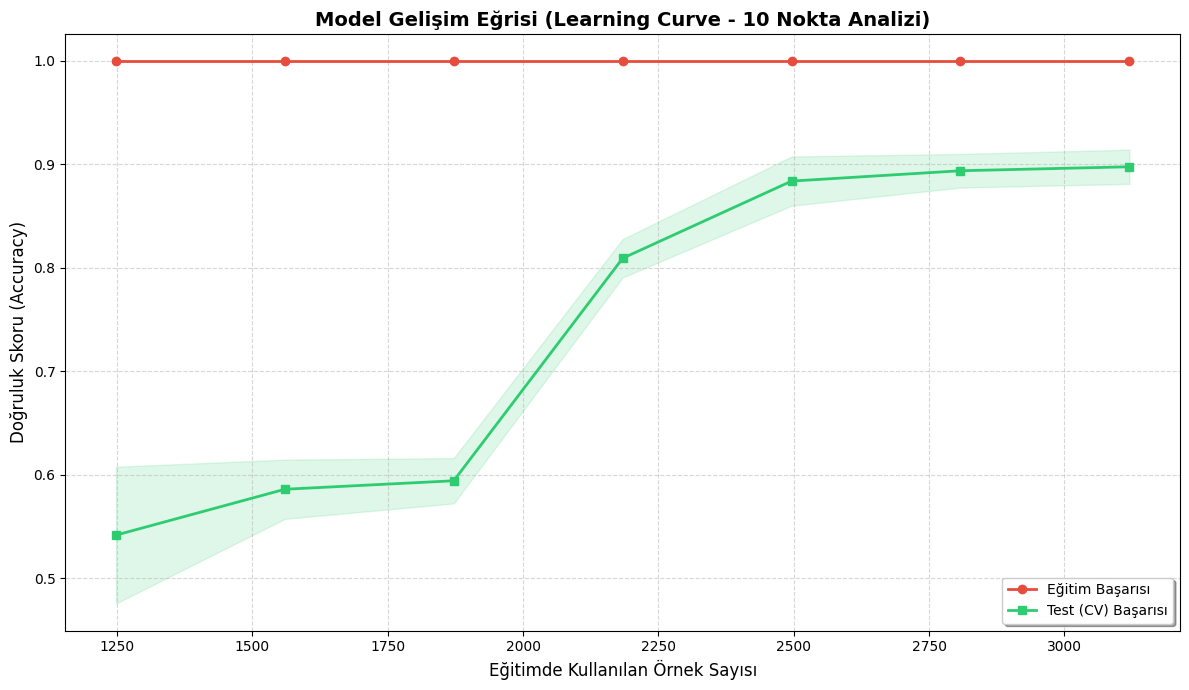

In [8]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

print(">>> Detaylı Öğrenme Eğrisi oluşturuluyor (10 Veri Noktası)...")

# Önemli: Veri noktası sayısını 10'a çıkardık (daha detaylı eğri için)
train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel='rbf', C=100, gamma=0.001), X_pca, y, 
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, n_jobs=-1
)

# Skor ortalamaları ve sapmaları
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 7))

# Eğitim Başarısı (Daha detaylı)
plt.plot(train_sizes, train_mean, 'o-', color="#E74C3C", label="Eğitim Başarısı", linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#E74C3C")

# Test Başarısı (Daha detaylı)
plt.plot(train_sizes, test_mean, 's-', color="#2ECC71", label="Test (CV) Başarısı", linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color="#2ECC71")

plt.title('Model Gelişim Eğrisi (Learning Curve - 10 Nokta Analizi)', fontsize=14, fontweight='bold')
plt.xlabel('Eğitimde Kullanılan Örnek Sayısı', fontsize=12)
plt.ylabel('Doğruluk Skoru (Accuracy)', fontsize=12)
plt.legend(loc="lower right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

>>> Hiperparametre Optimizasyonu Başlatıldı (16 Farklı Kombinasyon)...

--- GRID SEARCH TÜM DENEME SONUÇLARI (İLK 10) ---
 param_C  param_gamma  mean_test_score  std_test_score  rank_test_score
    10.0        0.001         0.903297        0.020669                1
   100.0        0.001         0.901465        0.019841                2
     1.0        0.001         0.897070        0.016842                3
     0.1        0.001         0.829670        0.010616                4
    10.0        0.010         0.672527        0.008305                5
   100.0        0.010         0.672527        0.008305                5
     1.0        0.010         0.649817        0.011074                7
     0.1        0.010         0.382784        0.008191                8
     1.0        0.100         0.350549        0.004426                9
    10.0        0.100         0.350549        0.004426                9


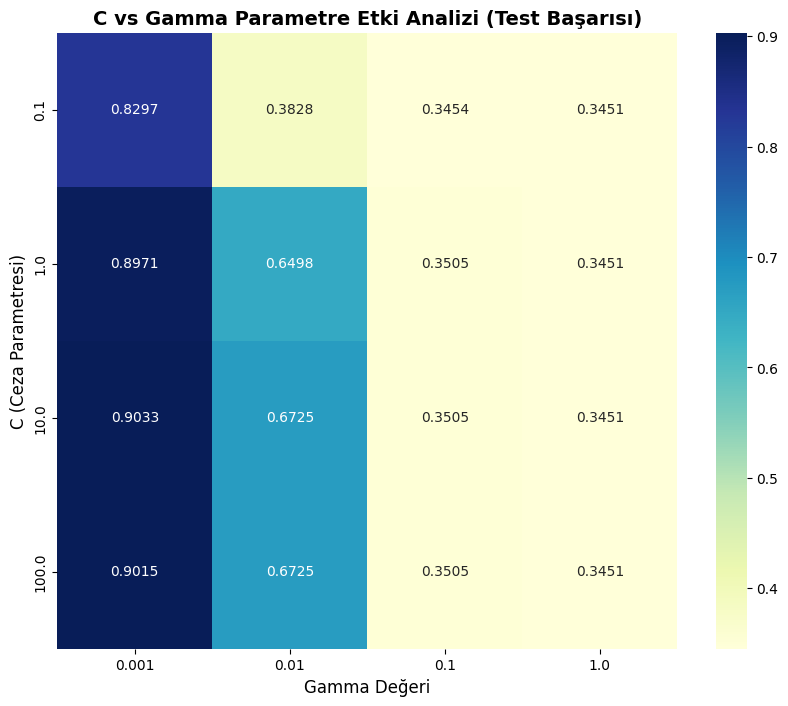


🏆 EN İYİ KOMBİNASYON: C=10, Gamma=0.001
🚀 EN YÜKSEK DOĞRULUK: %90.33


In [9]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import seaborn as sns

# Denenecek parametre havuzunu biraz daha genişletelim
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

print(">>> Hiperparametre Optimizasyonu Başlatıldı (16 Farklı Kombinasyon)...")
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv=5, return_train_score=True)
grid.fit(X_train, y_train)

# --- 1. TÜM SONUÇLARIN TABLOSU ---
results_df = pd.DataFrame(grid.cv_results_)
# Sadece önemli sütunları seçelim
display_columns = ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']
print("\n--- GRID SEARCH TÜM DENEME SONUÇLARI (İLK 10) ---")
print(results_df[display_columns].sort_values(by='rank_test_score').head(10).to_string(index=False))

# --- 2. ISI HARİTASI (HEATMAP) GÖRSELLEŞTİRMESİ ---
# Veriyi heatmap için pivot tablo haline getiriyoruz
viz_data = results_df.pivot(index='param_C', columns='param_gamma', values='mean_test_score')

plt.figure(figsize=(10, 8))
sns.heatmap(viz_data, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('C vs Gamma Parametre Etki Analizi (Test Başarısı)', fontsize=14, fontweight='bold')
plt.xlabel('Gamma Değeri', fontsize=12)
plt.ylabel('C (Ceza Parametresi)', fontsize=12)
plt.show()

print(f"\n🏆 EN İYİ KOMBİNASYON: C={grid.best_params_['C']}, Gamma={grid.best_params_['gamma']}")
print(f"🚀 EN YÜKSEK DOĞRULUK: %{grid.best_score_*100:.2f}")

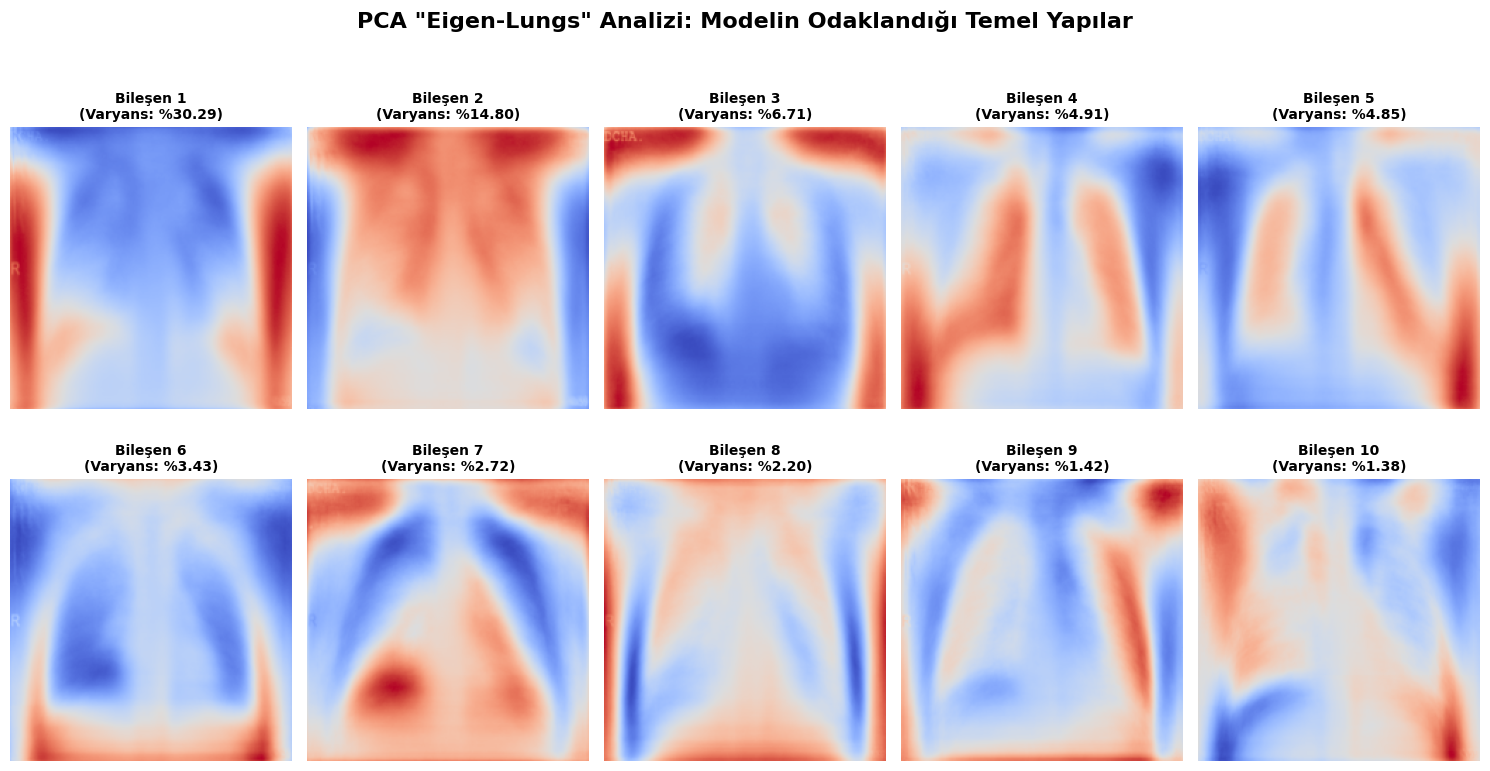


💡 SUNUM NOTU:
- Bu 'hayalet görüntüler', verideki en büyük bilgi farklarını (varyans) temsil eder.
- İlk bileşenler genelde genel akciğer yapısını (şekil, boyut) temsil ederken,
- Sonraki bileşenler daha ince detaylara ve patolojik belirtilere (COVID buzlu cam manzaraları gibi) odaklanır.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. PCA BİLEŞENLERİNİ GÖRSELLEŞTİRME (EIGEN-LUNGS)
# pca.components_ matrisi, her bir bileşenin orijinal piksel uzayındaki ağırlıklarını tutar.
eigen_lungs = pca.components_

plt.figure(figsize=(15, 8))
n_lungs_to_show = 10 # İlk 10 bileşeni gösterelim

for i in range(n_lungs_to_show):
    plt.subplot(2, 5, i + 1)
    
    # Bileşeni tekrar orijinal resim boyutuna (200x200) getiriyoruz
    lung_shape = eigen_lungs[i].reshape(200, 200)
    
    # 'coolwarm' veya 'gray' haritası ile görselleştirme
    plt.imshow(lung_shape, cmap='coolwarm') 
    
    plt.title(f'Bileşen {i+1}\n(Varyans: %{pca.explained_variance_ratio_[i]*100:.2f})', 
              fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle('PCA "Eigen-Lungs" Analizi: Modelin Odaklandığı Temel Yapılar', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 SUNUM NOTU:")
print("- Bu 'hayalet görüntüler', verideki en büyük bilgi farklarını (varyans) temsil eder.")
print("- İlk bileşenler genelde genel akciğer yapısını (şekil, boyut) temsil ederken,")
print("- Sonraki bileşenler daha ince detaylara ve patolojik belirtilere (COVID buzlu cam manzaraları gibi) odaklanır.")

>>> 10-Katlı Çapraz Doğrulama işlemi başlatıldı...
>>> Bu işlem modelin 10 kez farklı veri kümeleriyle eğitilmesini kapsar. Lütfen bekleyin...

--- 10-KATLI ÇAPRAZ DOĞRULAMA SONUÇLARI ---
Katman (Fold)  Doğruluk Skoru (Accuracy)
     Katman 1                   0.928205
     Katman 2                   0.900000
     Katman 3                   0.905128
     Katman 4                   0.928205
     Katman 5                   0.923077
     Katman 6                   0.902564
     Katman 7                   0.910256
     Katman 8                   0.910256
     Katman 9                   0.935897
    Katman 10                   0.933333

📊 ORTALAMA BAŞARI: %91.77
📉 STANDART SAPMA: ±%1.28


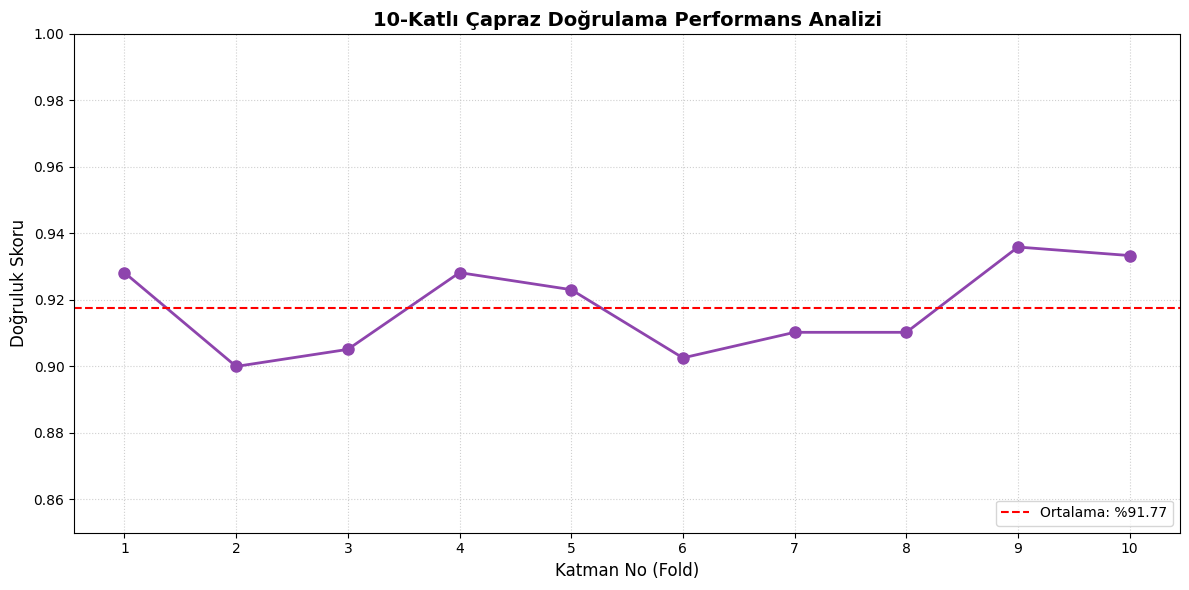

In [11]:
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. MODELİN VE ÇAPRAZ DOĞRULAMA YAPISININ KURULMASI
# Grid Search ile bulduğumuz en iyi parametreleri kullanıyoruz
best_svm = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)

# Veriyi 10 parçaya bölecek yapıyı kuruyoruz
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(">>> 10-Katlı Çapraz Doğrulama işlemi başlatıldı...")
print(">>> Bu işlem modelin 10 kez farklı veri kümeleriyle eğitilmesini kapsar. Lütfen bekleyin...\n")

# 2. İŞLEMİN GERÇEKLEŞTİRİLMESİ
# X_pca ve y tüm verimizi temsil eder (Dengeli veri setimiz)
scores = cross_val_score(best_svm, X_pca, y, cv=kf, n_jobs=-1)

# 3. SONUÇLARIN TABLO HALİNE GETİRİLMESİ
cv_results = pd.DataFrame({
    'Katman (Fold)': [f"Katman {i+1}" for i in range(10)],
    'Doğruluk Skoru (Accuracy)': scores
})

print("--- 10-KATLI ÇAPRAZ DOĞRULAMA SONUÇLARI ---")
print(cv_results.to_string(index=False))

mean_score = scores.mean() * 100
std_score = scores.std() * 100

print("\n" + "="*40)
print(f"📊 ORTALAMA BAŞARI: %{mean_score:.2f}")
print(f"📉 STANDART SAPMA: ±%{std_score:.2f}")
print("="*40)

# 4. PROFESYONEL GÖRSELLEŞTİRME (SUNUM İÇİN)
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), scores, marker='o', linestyle='-', color='#8E44AD', linewidth=2, markersize=8)
plt.axhline(y=scores.mean(), color='r', linestyle='--', label=f'Ortalama: %{mean_score:.2f}')

plt.title('10-Katlı Çapraz Doğrulama Performans Analizi', fontsize=14, fontweight='bold')
plt.xlabel('Katman No (Fold)', fontsize=12)
plt.ylabel('Doğruluk Skoru', fontsize=12)
plt.xticks(range(1, 11))
plt.ylim(scores.min() - 0.05, 1.0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

>>> Toplam Test Örneği: 585
>>> Hatalı Tahmin Sayısı: 50


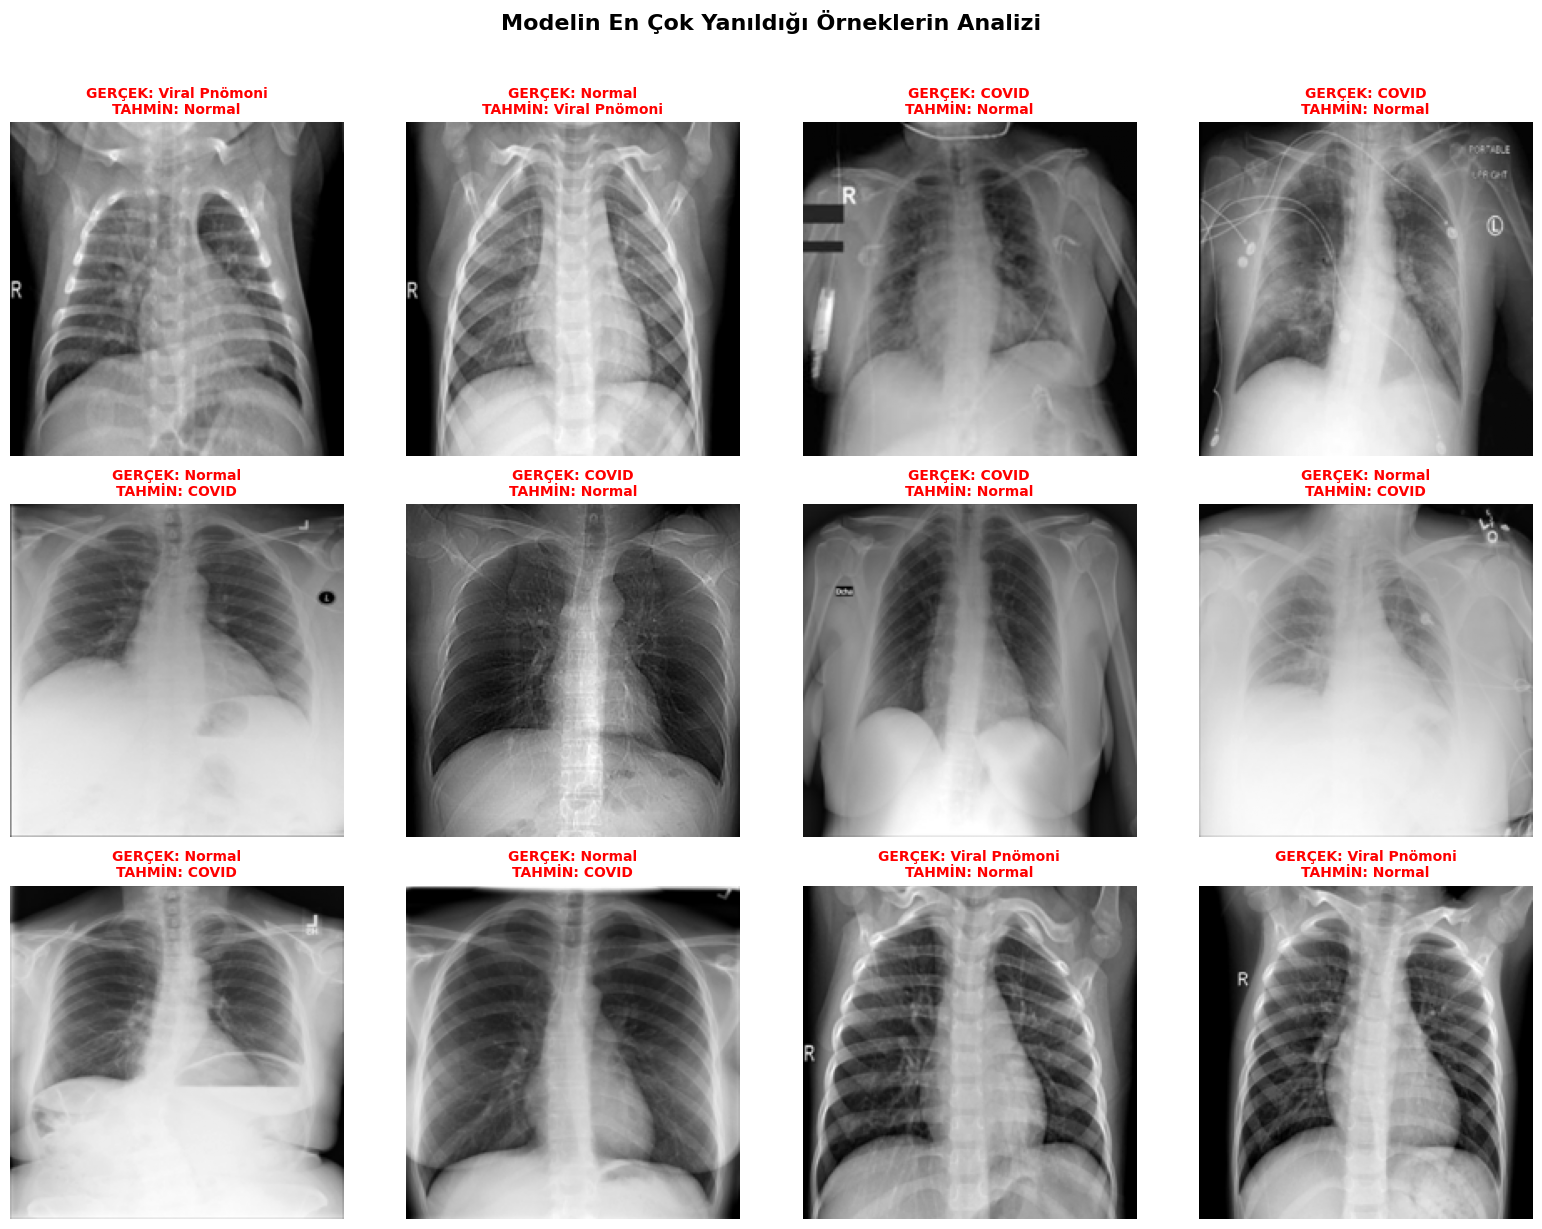


💡 SUNUM İÇİN TARTIŞMA NOTLARI:
- Hatalı resimlere bakıldığında, gürültü (noise) seviyesinin yüksek olduğu veya
  akciğer dokusunun diğer sınıflara çok benzediği görülebilir.
- Modelin özellikle COVID ve Normal vakaları karıştırdığı noktalar,
  hastalığın henüz başlangıç evresinde olduğu vakalar olabilir.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. TEST SETİ ÜZERİNDEKİ YANLIŞ TAHMİNLERİ TESPİT ETME
# Daha önce kullandığımız final_model (RBF) ile tahmin yapıyoruz
y_pred = final_model.predict(X_test)

# Yanlış tahmin edilen indeksleri buluyoruz
errors = np.where(y_pred != y_test)[0]
print(f">>> Toplam Test Örneği: {len(y_test)}")
print(f">>> Hatalı Tahmin Sayısı: {len(errors)}")

# 2. HATALI ÖRNEKLERİ GÖRSELLEŞTİRME
# Test setindeki verilerin orijinal 'X' dizisindeki (200x200 resimler) karşılığını bulmak için
# Aynı random_state ile indeksleri tekrar bölüyoruz
indices = np.arange(len(X))
_, indices_temp = train_test_split(indices, train_size=0.70, random_state=42, stratify=y)
_, indices_test = train_test_split(indices_temp, train_size=0.50, random_state=42, stratify=y_temp)

plt.figure(figsize=(16, 12))
n_show = min(len(errors), 12) # En fazla 12 hatayı gösterelim

for i in range(n_show):
    err_idx = errors[i] # Test setindeki hata indeksi
    original_idx = indices_test[err_idx] # Orijinal X dizisindeki resim indeksi
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(X[original_idx], cmap='gray')
    
    gercek_sinif = categories[y_test[err_idx]]
    tahmin_sinif = categories[y_pred[err_idx]]
    
    title_text = f"GERÇEK: {gercek_sinif}\nTAHMİN: {tahmin_sinif}"
    plt.title(title_text, color='red', fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle('Modelin En Çok Yanıldığı Örneklerin Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 SUNUM İÇİN TARTIŞMA NOTLARI:")
print("- Hatalı resimlere bakıldığında, gürültü (noise) seviyesinin yüksek olduğu veya")
print("  akciğer dokusunun diğer sınıflara çok benzediği görülebilir.")
print("- Modelin özellikle COVID ve Normal vakaları karıştırdığı noktalar,")
print("  hastalığın henüz başlangıç evresinde olduğu vakalar olabilir.")